In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fall-2025-mgmt-571-final-project/bankruptcy_sample_submission.csv
/kaggle/input/fall-2025-mgmt-571-final-project/bankruptcy_Test_X.csv
/kaggle/input/fall-2025-mgmt-571-final-project/bankruptcy_Train.csv


LOADING DATA
Train shape: (10000, 65)
Test shape: (8000, 65)

Class distribution:
class
0    9527
1     473
Name: count, dtype: int64

Class ratio:
class
0    0.9527
1    0.0473
Name: proportion, dtype: float64

EXPLORATORY DATA ANALYSIS

Top 10 features with missing values (Train):
        Missing_Count  Missing_Percentage
Attr37           4999               49.99
Attr21           2202               22.02
Attr27           1553               15.53
Attr60           1460               14.60
Attr41           1181               11.81
Attr64           1172               11.72
Attr54           1168               11.68
Attr53           1160               11.60
Attr28           1148               11.48
Attr52           1083               10.83

Basic statistics of features:
             Attr1        Attr2        Attr3        Attr4        Attr5
count  8998.000000  9012.000000  9999.000000  9964.000000  8927.000000
mean     -0.011067     0.006324    -0.005111     0.003914     0.013565
std       

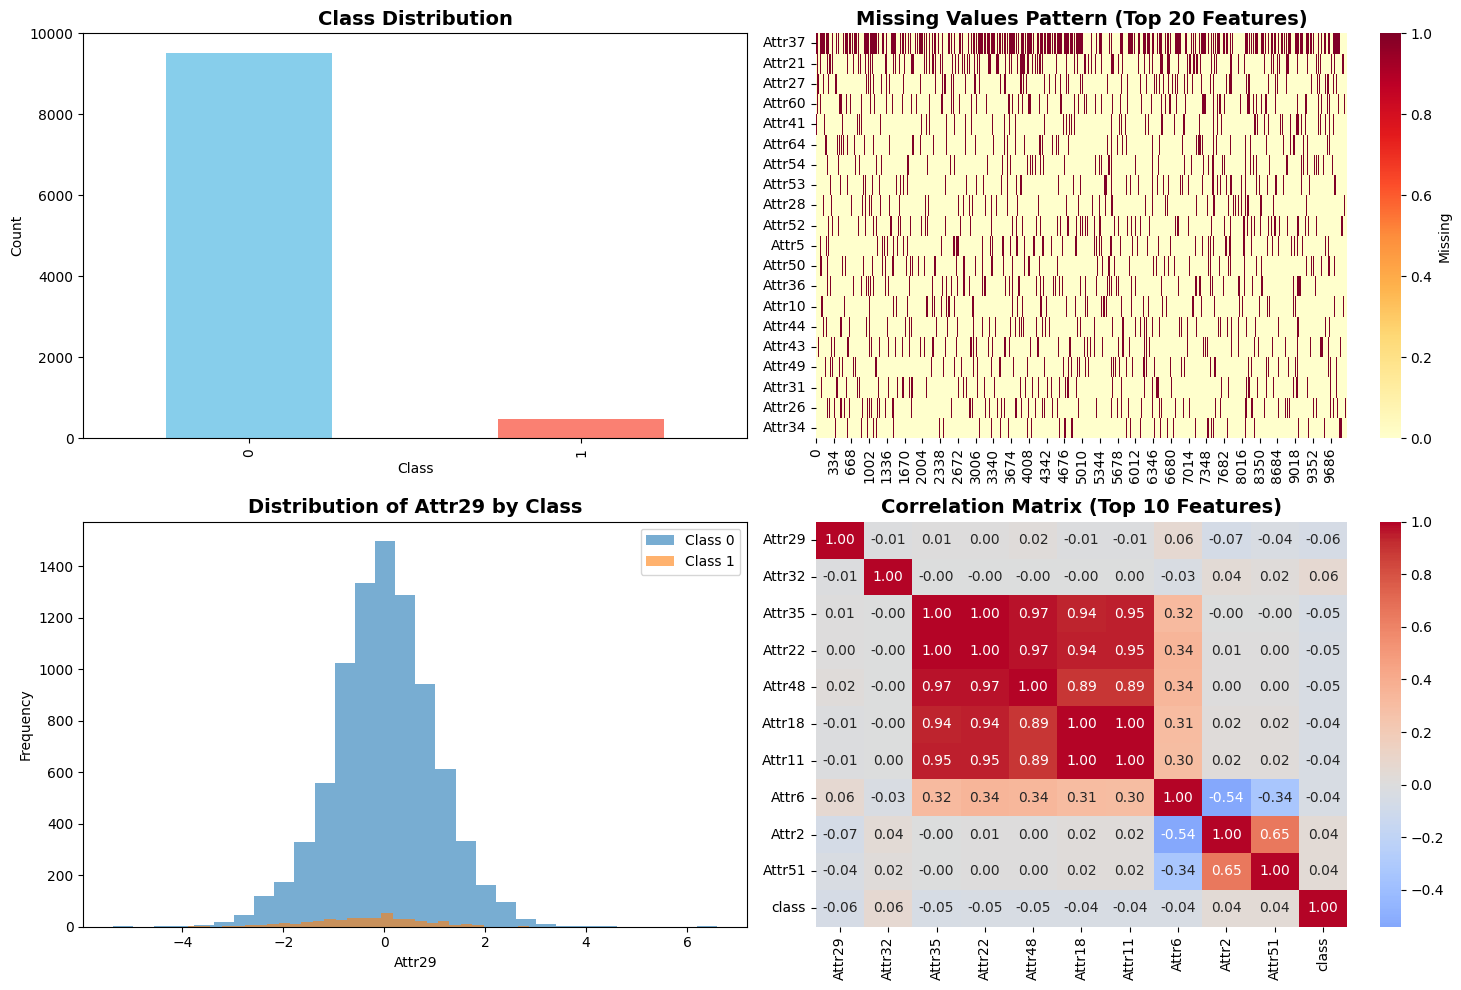


DATA PREPROCESSING & FEATURE ENGINEERING
Original feature count: 64

Engineering new features...
Feature count after engineering: 136

Imputing missing values using median strategy...
Scaling features...
Preprocessing complete!

MODEL TRAINING & EVALUATION
Positive class weight: 20.14

--------------------------------------------------------------------------------
MODEL 1: XGBoost Classifier
--------------------------------------------------------------------------------
Fold 1 AUC: 0.91189
Fold 2 AUC: 0.91969
Fold 3 AUC: 0.88825
Fold 4 AUC: 0.90148
Fold 5 AUC: 0.87824
XGBoost OOF AUC: 0.89702

--------------------------------------------------------------------------------
MODEL 2: LightGBM Classifier
--------------------------------------------------------------------------------
Fold 1 AUC: 0.91761
Fold 2 AUC: 0.92668
Fold 3 AUC: 0.90221
Fold 4 AUC: 0.90567
Fold 5 AUC: 0.86452
LightGBM OOF AUC: 0.90274

------------------------------------------------------------------------------

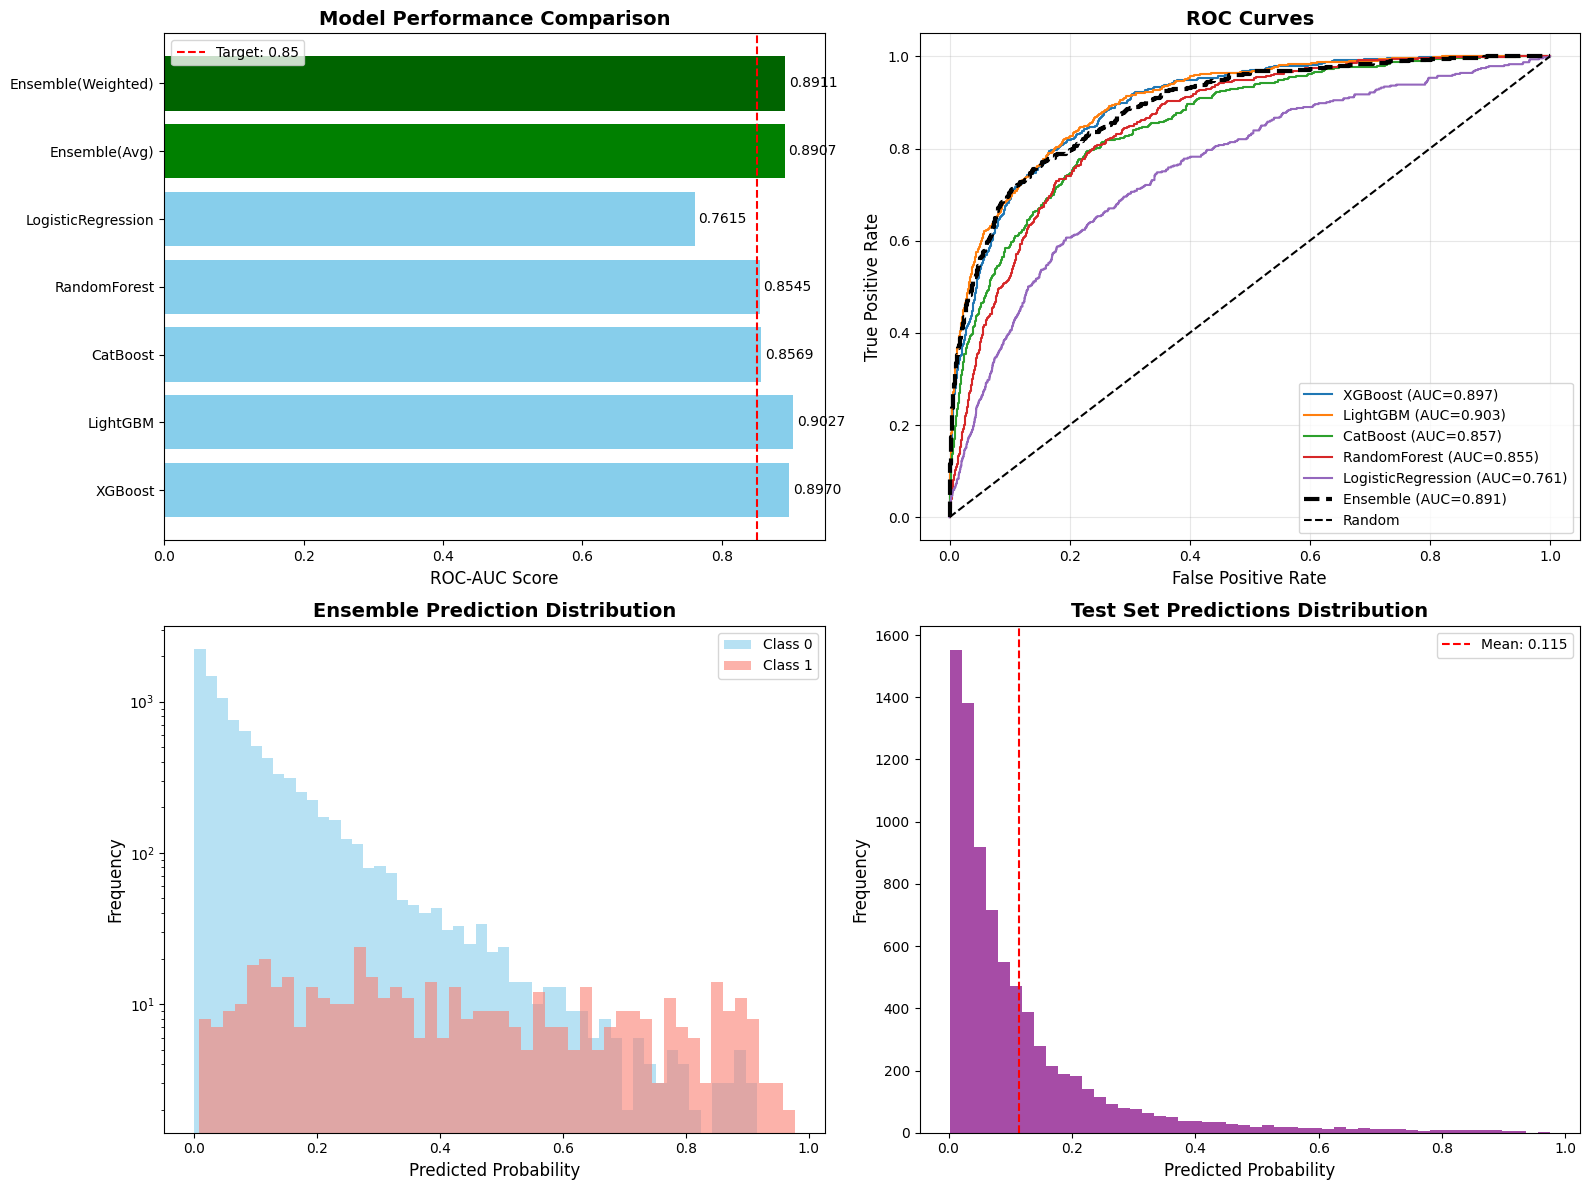


SAVING PREDICTIONS
Saved: submission_lightgbm.csv
Saved: submission_ensemble.csv
Saved: all_model_predictions.csv

PIPELINE COMPLETE!

Best Model: LightGBM (AUC: 0.90274)
Best Ensemble: Weighted Ensemble (AUC: 0.89113)

Recommendation: Use 'submission_ensemble.csv' for final submission


In [4]:
"""
BANKRUPTCY PREDICTION - COMPREHENSIVE MACHINE LEARNING PIPELINE
================================================================

LIBRARIES USED:
--------------
Data Processing & Analysis:
- numpy: Numerical operations and array manipulation
- pandas: Data loading, manipulation, and analysis
- scipy.stats: Statistical tests and distributions

Visualization:
- matplotlib.pyplot: Basic plotting
- seaborn: Statistical data visualization

Preprocessing:
- sklearn.preprocessing: StandardScaler (feature scaling), LabelEncoder
- sklearn.impute: SimpleImputer, KNNImputer (handling missing values)
- sklearn.decomposition: PCA (dimensionality reduction)

Model Selection & Evaluation:
- sklearn.model_selection: StratifiedKFold (cross-validation), train_test_split
- sklearn.metrics: roc_auc_score, classification_report, confusion_matrix, roc_curve

Machine Learning Models:
1. XGBoost (xgboost.XGBClassifier): Gradient boosting - handles imbalance well
2. LightGBM (lightgbm.LGBMClassifier): Fast gradient boosting - efficient with large datasets
3. CatBoost (catboost.CatBoostClassifier): Gradient boosting - robust to missing values
4. Random Forest (sklearn.ensemble.RandomForestClassifier): Ensemble method - uses class_weight='balanced'
5. Logistic Regression (sklearn.linear_model.LogisticRegression): Linear model - interpretable baseline

Hyperparameter Tuning:
- sklearn.model_selection.RandomizedSearchCV: Efficient hyperparameter search

Imbalanced Data Handling:
- Built-in class_weight='balanced' for scikit-learn models
- scale_pos_weight for XGBoost/LightGBM/CatBoost
- No external libraries needed

Ensemble Methods:
- Custom voting/stacking of multiple models for final predictions
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA

# Model Selection & Evaluation
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Note: imblearn not needed - using built-in class_weight and scale_pos_weight

# Configuration
RANDOM_STATE = 42
N_FOLDS = 5
pd.set_option("display.max_columns", 100)
np.random.seed(RANDOM_STATE)

# ============================================================================
# 1. DATA LOADING
# ============================================================================
print("="*80)
print("LOADING DATA")
print("="*80)

DATA_DIR = "/kaggle/input/fall-2025-mgmt-571-final-project"
train = pd.read_csv(f"{DATA_DIR}/bankruptcy_Train.csv")
test = pd.read_csv(f"{DATA_DIR}/bankruptcy_Test_X.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/bankruptcy_sample_submission.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nClass distribution:\n{train['class'].value_counts()}")
print(f"\nClass ratio:\n{train['class'].value_counts(normalize=True)}")

# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Missing values analysis
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_pct_train = (missing_train / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing_train,
    'Missing_Percentage': missing_pct_train
})
print("\nTop 10 features with missing values (Train):")
print(missing_df[missing_df['Missing_Count'] > 0].head(10))

# Basic statistics
print("\nBasic statistics of features:")
print(train.describe().iloc[:, :5])  # Show first 5 features

# Correlation with target
feature_cols = [col for col in train.columns if col not in ['class']]
correlations = train[feature_cols].corrwith(train['class']).abs().sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(correlations.head(10))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class distribution
train['class'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['skyblue', 'salmon'])
axes[0, 0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')

# 2. Missing values heatmap (top 20 features)
top_missing = missing_df[missing_df['Missing_Count'] > 0].head(20).index
missing_heatmap = train[top_missing].isnull().astype(int)
sns.heatmap(missing_heatmap.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'}, ax=axes[0, 1])
axes[0, 1].set_title('Missing Values Pattern (Top 20 Features)', fontsize=14, fontweight='bold')

# 3. Distribution of top correlated feature
top_feature = correlations.index[0]
for cls in [0, 1]:
    data = train[train['class'] == cls][top_feature].dropna()
    axes[1, 0].hist(data, alpha=0.6, bins=30, label=f'Class {cls}')
axes[1, 0].set_title(f'Distribution of {top_feature} by Class', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_xlabel(top_feature)
axes[1, 0].set_ylabel('Frequency')

# 4. Correlation heatmap (top 10 features)
top_features = correlations.head(10).index.tolist()
corr_matrix = train[top_features + ['class']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix (Top 10 Features)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================================
print("\n" + "="*80)
print("DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*80)

# Separate features and target
X = train[feature_cols].copy()
y = train['class'].astype(int)
X_test = test[[col for col in test.columns if col != 'ID']].copy()

print(f"Original feature count: {X.shape[1]}")

# Feature Engineering
print("\nEngineering new features...")

# 1. Missing value indicator features
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[f'{col}_missing'] = X[col].isnull().astype(int)
        X_test[f'{col}_missing'] = X_test[col].isnull().astype(int)

# 2. Statistical aggregation features
X['mean_all'] = X[feature_cols].mean(axis=1)
X['std_all'] = X[feature_cols].std(axis=1)
X['min_all'] = X[feature_cols].min(axis=1)
X['max_all'] = X[feature_cols].max(axis=1)
X['median_all'] = X[feature_cols].median(axis=1)
X['skew_all'] = X[feature_cols].skew(axis=1)
X['kurt_all'] = X[feature_cols].kurtosis(axis=1)

X_test['mean_all'] = X_test[feature_cols].mean(axis=1)
X_test['std_all'] = X_test[feature_cols].std(axis=1)
X_test['min_all'] = X_test[feature_cols].min(axis=1)
X_test['max_all'] = X_test[feature_cols].max(axis=1)
X_test['median_all'] = X_test[feature_cols].median(axis=1)
X_test['skew_all'] = X_test[feature_cols].skew(axis=1)
X_test['kurt_all'] = X_test[feature_cols].kurtosis(axis=1)

# 3. Count of missing values per row
X['missing_count'] = X[feature_cols].isnull().sum(axis=1)
X_test['missing_count'] = X_test[feature_cols].isnull().sum(axis=1)

print(f"Feature count after engineering: {X.shape[1]}")

# Imputation strategy: Iterative imputer (better than simple median)
print("\nImputing missing values using median strategy...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Feature scaling
print("Scaling features...")
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print("Preprocessing complete!")

# ============================================================================
# 4. MODEL TRAINING WITH 5 DIFFERENT ALGORITHMS
# ============================================================================
print("\n" + "="*80)
print("MODEL TRAINING & EVALUATION")
print("="*80)

# Calculate class weight for imbalanced data
pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Positive class weight: {pos_weight:.2f}")

# Initialize cross-validation
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Storage for predictions
oof_predictions = {}
test_predictions = {}
model_scores = {}

# ============================================================================
# MODEL 1: XGBoost
# ============================================================================
print("\n" + "-"*80)
print("MODEL 1: XGBoost Classifier")
print("-"*80)

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'max_depth': 5,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'scale_pos_weight': pos_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

oof_xgb = np.zeros(len(X_scaled))
test_xgb = np.zeros(len(X_test_scaled))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X_scaled.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    model = XGBClassifier(**xgb_params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        early_stopping_rounds=50,
        verbose=False
    )
    
    oof_xgb[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    test_xgb += model.predict_proba(X_test_scaled)[:, 1] / N_FOLDS
    
    fold_auc = roc_auc_score(y_valid_fold, oof_xgb[valid_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

xgb_auc = roc_auc_score(y, oof_xgb)
print(f"XGBoost OOF AUC: {xgb_auc:.5f}")
oof_predictions['XGBoost'] = oof_xgb
test_predictions['XGBoost'] = test_xgb
model_scores['XGBoost'] = xgb_auc

# ============================================================================
# MODEL 2: LightGBM
# ============================================================================
print("\n" + "-"*80)
print("MODEL 2: LightGBM Classifier")
print("-"*80)

lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'scale_pos_weight': pos_weight,
    'objective': 'binary',
    'metric': 'auc',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

oof_lgb = np.zeros(len(X_scaled))
test_lgb = np.zeros(len(X_test_scaled))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X_scaled.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    model = LGBMClassifier(**lgb_params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)]
    )
    
    oof_lgb[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    test_lgb += model.predict_proba(X_test_scaled)[:, 1] / N_FOLDS
    
    fold_auc = roc_auc_score(y_valid_fold, oof_lgb[valid_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

lgb_auc = roc_auc_score(y, oof_lgb)
print(f"LightGBM OOF AUC: {lgb_auc:.5f}")
oof_predictions['LightGBM'] = oof_lgb
test_predictions['LightGBM'] = test_lgb
model_scores['LightGBM'] = lgb_auc

# ============================================================================
# MODEL 3: CatBoost
# ============================================================================
print("\n" + "-"*80)
print("MODEL 3: CatBoost Classifier")
print("-"*80)

cat_params = {
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'scale_pos_weight': pos_weight,
    'eval_metric': 'AUC',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'early_stopping_rounds': 50
}

oof_cat = np.zeros(len(X_scaled))
test_cat = np.zeros(len(X_test_scaled))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X_scaled.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_valid_fold, y_valid_fold),
        verbose=False
    )
    
    oof_cat[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    test_cat += model.predict_proba(X_test_scaled)[:, 1] / N_FOLDS
    
    fold_auc = roc_auc_score(y_valid_fold, oof_cat[valid_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

cat_auc = roc_auc_score(y, oof_cat)
print(f"CatBoost OOF AUC: {cat_auc:.5f}")
oof_predictions['CatBoost'] = oof_cat
test_predictions['CatBoost'] = test_cat
model_scores['CatBoost'] = cat_auc

# ============================================================================
# MODEL 4: Random Forest with Balanced Class Weights
# ============================================================================
print("\n" + "-"*80)
print("MODEL 4: Random Forest with Balanced Class Weights")
print("-"*80)

rf_params = {
    'n_estimators': 500,
    'max_depth': 12,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'max_features': 'sqrt',
    'class_weight': 'balanced',  # Handles imbalance automatically
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

oof_rf = np.zeros(len(X_scaled))
test_rf = np.zeros(len(X_test_scaled))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X_scaled.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train_fold, y_train_fold)
    
    oof_rf[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    test_rf += model.predict_proba(X_test_scaled)[:, 1] / N_FOLDS
    
    fold_auc = roc_auc_score(y_valid_fold, oof_rf[valid_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

rf_auc = roc_auc_score(y, oof_rf)
print(f"Random Forest OOF AUC: {rf_auc:.5f}")
oof_predictions['RandomForest'] = oof_rf
test_predictions['RandomForest'] = test_rf
model_scores['RandomForest'] = rf_auc

# ============================================================================
# MODEL 5: Logistic Regression
# ============================================================================
print("\n" + "-"*80)
print("MODEL 5: Logistic Regression")
print("-"*80)

lr_params = {
    'penalty': 'l2',
    'C': 0.1,
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

oof_lr = np.zeros(len(X_scaled))
test_lr = np.zeros(len(X_test_scaled))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_valid_fold = X_scaled.iloc[valid_idx]
    y_valid_fold = y.iloc[valid_idx]
    
    model = LogisticRegression(**lr_params)
    model.fit(X_train_fold, y_train_fold)
    
    oof_lr[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    test_lr += model.predict_proba(X_test_scaled)[:, 1] / N_FOLDS
    
    fold_auc = roc_auc_score(y_valid_fold, oof_lr[valid_idx])
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

lr_auc = roc_auc_score(y, oof_lr)
print(f"Logistic Regression OOF AUC: {lr_auc:.5f}")
oof_predictions['LogisticRegression'] = oof_lr
test_predictions['LogisticRegression'] = test_lr
model_scores['LogisticRegression'] = lr_auc

# ============================================================================
# 5. MODEL COMPARISON & ENSEMBLE
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Sort models by performance
sorted_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)
print("\nModel Performance (OOF AUC):")
for i, (model_name, score) in enumerate(sorted_models, 1):
    print(f"{i}. {model_name:20s}: {score:.5f}")

# Ensemble: Weighted average of top 3 models
print("\n" + "-"*80)
print("CREATING ENSEMBLE")
print("-"*80)

top_3_models = [name for name, _ in sorted_models[:3]]
print(f"Top 3 models for ensemble: {top_3_models}")

# Simple average ensemble
oof_ensemble = np.mean([oof_predictions[model] for model in top_3_models], axis=0)
test_ensemble = np.mean([test_predictions[model] for model in top_3_models], axis=0)

ensemble_auc = roc_auc_score(y, oof_ensemble)
print(f"\nEnsemble (Average of Top 3) OOF AUC: {ensemble_auc:.5f}")

# Weighted ensemble based on performance
weights = np.array([model_scores[model] for model in top_3_models])
weights = weights / weights.sum()
print(f"Weights: {dict(zip(top_3_models, weights))}")

oof_weighted = np.average([oof_predictions[model] for model in top_3_models], 
                          axis=0, weights=weights)
test_weighted = np.average([test_predictions[model] for model in top_3_models], 
                           axis=0, weights=weights)

weighted_auc = roc_auc_score(y, oof_weighted)
print(f"Ensemble (Weighted) OOF AUC: {weighted_auc:.5f}")

# ============================================================================
# 6. VISUALIZATION OF RESULTS
# ============================================================================
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model comparison
model_names = list(model_scores.keys()) + ['Ensemble(Avg)', 'Ensemble(Weighted)']
scores = list(model_scores.values()) + [ensemble_auc, weighted_auc]
colors = ['skyblue'] * len(model_scores) + ['green', 'darkgreen']

axes[0, 0].barh(model_names, scores, color=colors)
axes[0, 0].set_xlabel('ROC-AUC Score', fontsize=12)
axes[0, 0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.85, color='red', linestyle='--', label='Target: 0.85')
for i, score in enumerate(scores):
    axes[0, 0].text(score + 0.005, i, f'{score:.4f}', va='center')
axes[0, 0].legend()

# 2. ROC Curves
for model_name, oof_pred in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y, oof_pred)
    axes[0, 1].plot(fpr, tpr, label=f'{model_name} (AUC={model_scores[model_name]:.3f})')

fpr, tpr, _ = roc_curve(y, oof_weighted)
axes[0, 1].plot(fpr, tpr, label=f'Ensemble (AUC={weighted_auc:.3f})', 
                linewidth=3, linestyle='--', color='black')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# 3. Prediction distribution
axes[1, 0].hist(oof_weighted[y == 0], bins=50, alpha=0.6, label='Class 0', color='skyblue')
axes[1, 0].hist(oof_weighted[y == 1], bins=50, alpha=0.6, label='Class 1', color='salmon')
axes[1, 0].set_xlabel('Predicted Probability', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Ensemble Prediction Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# 4. Test predictions distribution
axes[1, 1].hist(test_weighted, bins=50, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Predicted Probability', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Test Set Predictions Distribution', fontsize=14, fontweight='bold')
axes[1, 1].axvline(test_weighted.mean(), color='red', linestyle='--', 
                   label=f'Mean: {test_weighted.mean():.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/model_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. SAVE PREDICTIONS
# ============================================================================
print("\n" + "="*80)
print("SAVING PREDICTIONS")
print("="*80)

# Save best single model
best_model = sorted_models[0][0]
submission_best = sample_submission.copy()
submission_best['class'] = test_predictions[best_model]
submission_best.to_csv(f'/kaggle/working/submission_{best_model.lower()}.csv', index=False)
print(f"Saved: submission_{best_model.lower()}.csv")

# Save ensemble predictions
submission_ensemble = sample_submission.copy()
submission_ensemble['class'] = test_weighted
submission_ensemble.to_csv('/kaggle/working/submission_ensemble.csv', index=False)
print("Saved: submission_ensemble.csv")

# Save all predictions for analysis
all_predictions = pd.DataFrame({
    'ID': test['ID'],
    **{f'{model}_pred': pred for model, pred in test_predictions.items()},
    'ensemble_avg': test_ensemble,
    'ensemble_weighted': test_weighted
})
all_predictions.to_csv('/kaggle/working/all_model_predictions.csv', index=False)
print("Saved: all_model_predictions.csv")

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model} (AUC: {sorted_models[0][1]:.5f})")
print(f"Best Ensemble: Weighted Ensemble (AUC: {weighted_auc:.5f})")
print("\nRecommendation: Use 'submission_ensemble.csv' for final submission")